In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Predicting resale price of used heavy equipment

We are given ~139k auction records of used industrial machinery and must predict the sale price of 15k unseen machines.

The metric is **RMSLE** — root mean squared error measured on log prices. That single fact drives the first design decision of the whole notebook: I train on `log1p(TargetValue)` rather than the raw price, so the model's loss function is the leaderboard metric. Predicting a 10k USD machine at 20k USD should hurt as much as predicting a 100k USD machine at 200k USD, and only the log scale expresses that.

---
## Data-Science Lifecycle followed in this notebook
1. **Problem framing & data loading**
2. **Data understanding** — shapes, types, target, missingness
3. **Exploratory Data Analysis (EDA)** — distributions, missing-value profile, correlations, relationships
4. **Data cleaning & missing-value handling**
5. **Feature engineering** (leakage-free, applied identically to train & test)
6. **Encoding & preprocessing** wired through `Pipeline` / `ColumnTransformer` (no leakage)
7. **Modelling** — three different model families
8. **Hyperparameter tuning** (RandomizedSearchCV) on one model
9. **Model comparison table** + performance analysis & insights
10. **Final model & submission**



## 1. Setup & data loading

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
TARGET = "TargetValue"

In [ ]:
# data loading.

train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv",low_memory = False)
test=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
# train=pd.read_csv('train.csv')
# test=pd.read_csv('test.csv')
print("train :", train.shape)
print("test :", test.shape)

train : (138701, 50)
test : (15000, 49)


## 2. Data understanding

In [5]:
# What is the target, and which columns exist only in train?
print("Target present only in train:", set(train.columns) - set(test.columns))

# dtype
print("\nColumn dtype counts:")
print(train.dtypes.value_counts())

Target present only in train: {'TargetValue'}

Column dtype counts:
object     44
int64       4
float64     2
Name: count, dtype: int64


**Observations**
- `TargetValue` is the only column absent from the test set ,confirmed as the prediction target.


## 3. Exploratory Data Analysis
Before engineering any features, I want to answer four key questions:

 1. What does the target distribution look like?
 2. How much data is missing, and is the missingness informative?
 3. How strongly do age and usage influence the sale price?
 4. Do the categorical features meaningfully distinguish between different price levels?

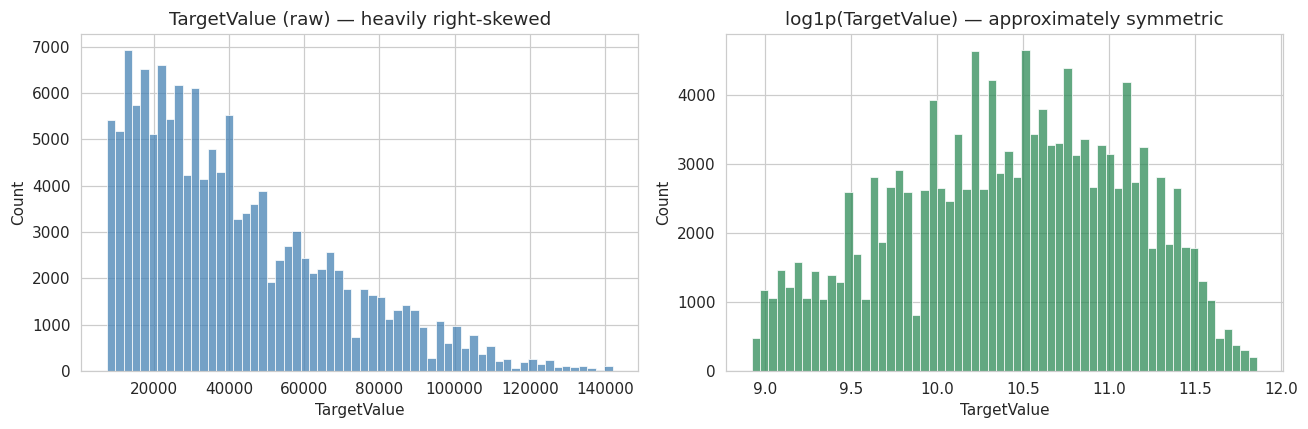

Raw   skew: 0.97
log1p skew: -0.198


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train[TARGET], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title("TargetValue (raw) — heavily right-skewed")
#usinglog1p because the small values remain small and the large values dont blow up nd moreove log(0) exists
sns.histplot(np.log1p(train[TARGET]), bins=60, ax=axes[1], color="seagreen")
axes[1].set_title("log1p(TargetValue) — approximately symmetric")
plt.tight_layout(); plt.show()

print("Raw   skew:", round(train[TARGET].skew(), 3))
print("log1p skew:", round(np.log1p(train[TARGET]).skew(), 3))

**Observation:** raw prices are strongly right-skewed; `log1p` makes the distribution roughly
symmetric. Because the metric is RMSLE, modelling `log1p(TargetValue)` is the natural choice — RMSE on
the log target *is* the RMSLE.

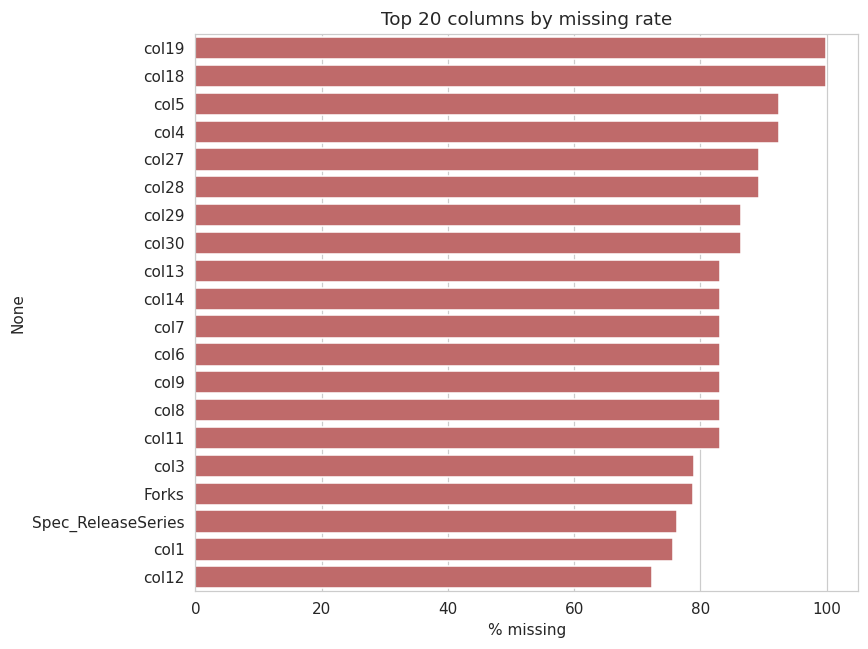

In [7]:
missing_pct = train.isnull().mean().sort_values(ascending=False).head(20) * 100
plt.figure(figsize=(8, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="indianred")
plt.xlabel("% missing"); plt.title("Top 20 columns by missing rate")
plt.tight_layout(); plt.show()

**Observation:** `col18`/`col19` are ~99.95% empty; a broader `col*` family is very sparse. These are
dropped above a 99.9% threshold. Moderately missing columns (e.g. `OperationalHoursMeter`,
`Spec_VariantModifier`) are kept — their *missingness itself* is predictive, so we add explicit
missing-indicator flags.

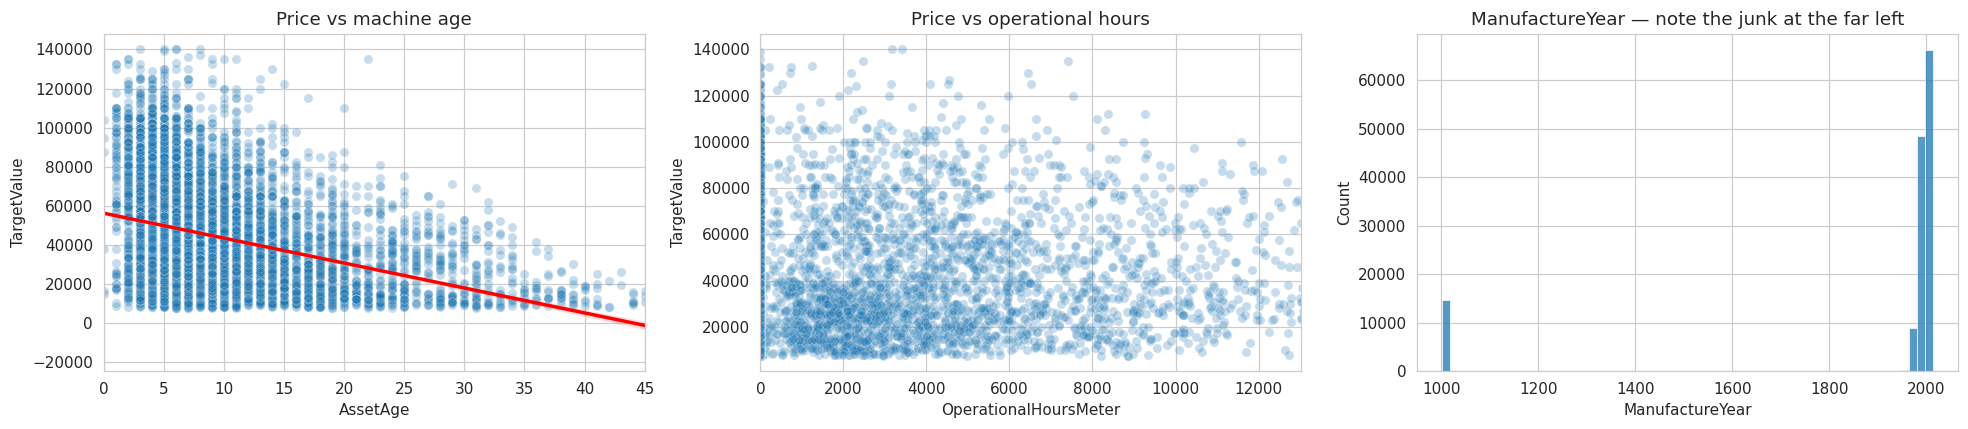

corr(TargetValue, OperationalHoursMeter): 0.002
Mode of ManufactureYear: 1001
Rows with OperationalHoursMeter == 0: 31583


In [8]:
tmp = train.copy()
tmp['SaleYear'] = pd.to_datetime(tmp['TransactionDate']).dt.year
tmp['MY'] = tmp['ManufactureYear'].where(tmp['ManufactureYear'] > 1900, np.nan)
tmp['AssetAge'] = tmp['SaleYear'] - tmp['MY']
sample = tmp.sample(8000, random_state=42)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

sns.scatterplot(x='AssetAge', y='TargetValue', data=sample, alpha=.25, ax=ax[0])
sns.regplot(x='AssetAge', y='TargetValue', data=sample, scatter=False,
            color='red', ax=ax[0])
ax[0].set_xlim(0, 45); ax[0].set_title('Price vs machine age')

sns.scatterplot(x='OperationalHoursMeter', y='TargetValue', data=sample,
                alpha=.25, ax=ax[1])
ax[1].set_xlim(0, tmp['OperationalHoursMeter'].quantile(.95))
ax[1].set_title('Price vs operational hours')

sns.histplot(train['ManufactureYear'], bins=60, ax=ax[2])
ax[2].set_title('ManufactureYear — note the junk at the far left')

plt.tight_layout(); plt.show()

print("corr(TargetValue, OperationalHoursMeter):",
      round(train['TargetValue'].corr(train['OperationalHoursMeter']), 4))
print("Mode of ManufactureYear:", train['ManufactureYear'].mode()[0])
print("Rows with OperationalHoursMeter == 0:",
      (train['OperationalHoursMeter'] == 0).sum())

**Three observations, three actions.**

**(a) Age matters.** The relationship is clearly negative, making age an important feature. However, it cannot be calculated directly because of the issue described in (c).

**(b) Operational hours appears unhelpful—but that's misleading.** Its correlation with price is only 0.002, suggesting almost no relationship. But the plot reveals a large spike at **0 hours**. A used machine with truly zero operating hours is unrealistic. Here, **0 indicates that the meter reading is missing, not that the machine was unused.** If left unchanged, the model may incorrectly associate missing readings with lower prices. The solution is to replace 0 with `NaN` and create a `HasOperationalHours` indicator so the missing information itself remains available to the model. 

**(c) ManufactureYear includes invalid placeholder values.** The most common value is **1001**, which is clearly not a real manufacturing year. Using it would produce impossible ages of nearly 1000 years. Therefore, years before 1900 are converted to `NaN`, and any negative ages (where the sale year is earlier than the manufacture year) are also treated as missing.

In [25]:
for c in ['UtilizationTier', 'CabinType', 'RegionCode', 'FunctionalClassification',
          'Spec_BaseClass', 'AssetID']:
    print(f"{c:28s} {train[c].nunique():>6d} unique")

UtilizationTier                   3 unique
CabinType                         3 unique
RegionCode                       53 unique
FunctionalClassification         65 unique
Spec_BaseClass                 1249 unique
AssetID                      120111 unique


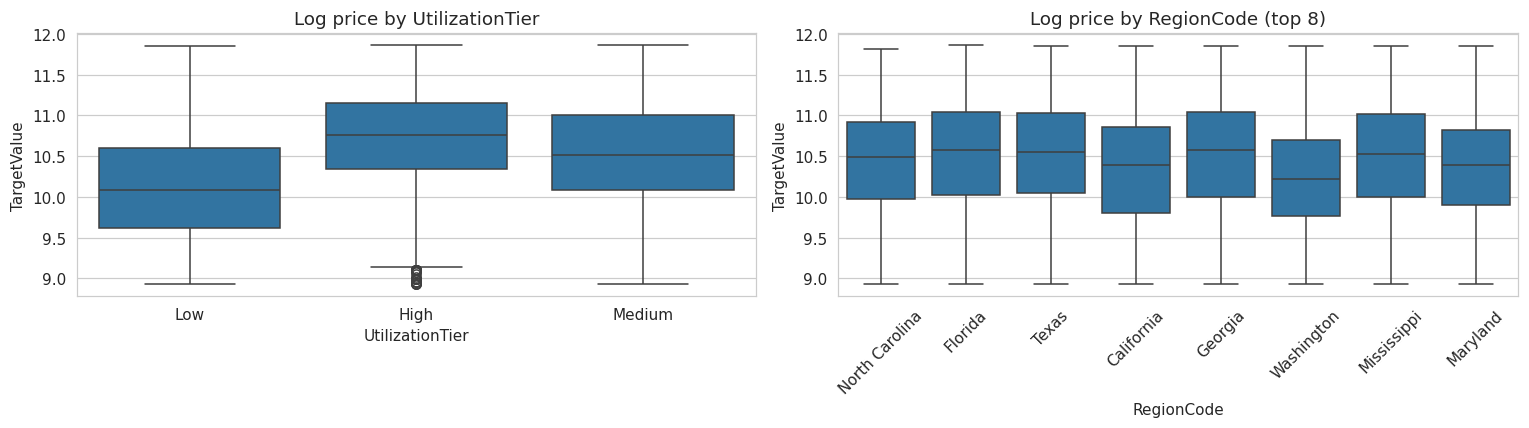


Example FunctionalClassification values:
['Wheel Loader - 150.0 to 175.0 Horsepower'
 'Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth'
 'Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons']


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

#performed this to see the influence on the targetv
sns.boxplot(x='UtilizationTier', y=np.log1p(tmp['TargetValue']), data=tmp, ax=ax[0])
ax[0].set_title('Log price by UtilizationTier')

top_states = tmp['RegionCode'].value_counts().head(8).index
sns.boxplot(x='RegionCode', y=np.log1p(tmp['TargetValue']),
            data=tmp[tmp['RegionCode'].isin(top_states)], ax=ax[1])
ax[1].set_title('Log price by RegionCode (top 8)')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()



print("\nExample FunctionalClassification values:")
print(train['FunctionalClassification'].dropna().unique()[:3])

**Key observations, key choices.**

**Finding.** `UtilizationTier` shows a clear difference in sale prices across its categories, while `RegionCode` contributes very little since the price distributions largely overlap. The bigger concern is cardinality: `Spec_BaseClass` contains **1,249** unique values, and `AssetID` has even more.

**Encoding strategy.** Applying one-hot encoding to thousands of categories would create an extremely sparse feature matrix and increase training cost. Instead, I use different encoding methods based on the feature:

* **Low-cardinality features (≤15 categories):** use LightGBM's native categorical handling, which efficiently splits on category groups.
* **High-cardinality identifiers:** apply **count encoding** together with **target encoding** to capture both category frequency and its relationship with the target.
* **`FunctionalClassification`:** extract structured information instead of treating it as a plain category.

The sample values above, such as **"Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons"**, contain more than just labels—they embed useful numerical information. Machine capacity, whether expressed as tonnage or horsepower, is a major factor affecting resale price. Treating the entire string as a categorical value would ignore this signal, so I extract the size range using regular expressions and convert it into a usable numerical feature.

## 4. Data cleaning & feature engineering

All transformations below are **row-wise** — each row is computed from its own values only, with **no
use of the target and no cross-row statistics**  so the *same* function is applied to train and test
with zero leakage. (Target-based encoding, which *does* need care, is handled separately in Section 6
using out-of-fold estimation.)

Cleaning / engineering steps:
- Parse `TransactionDate` → `SaleYear`, `SaleMonth`, `SaleQuarter`.
- Fix the `ManufactureYear` sentinel anomalies (`1000`, `1001` → `NaN`).
- `AssetAge = SaleYear − ManufactureYear`, plus `AgeSquared` for non-linearity.
- Usage intensity: `HoursPerYear`, `LogHours`, `UsagePerAge`.
- Text signals from `Spec_FullDescriptor` (length, word/digit/upper/slash counts).
- Missing-indicator flags for columns whose absence is informative.
- Drop columns that are >99.9% empty.


In [10]:
MISSING_FLAG_COLS = ["OperationalHoursMeter", "ManufactureYear","Spec_VariantModifier", "Spec_ReleaseSeries", "Forks"]

def feature_engineer(df):
    """Leakage-free, purely row-wise feature engineering (identical for train & test)."""
    df = df.copy()

    # --- date parts ---
    df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")
    df["SaleYear"]    = df["TransactionDate"].dt.year
    df["SaleMonth"]   = df["TransactionDate"].dt.month
    df["SaleQuarter"] = df["TransactionDate"].dt.quarter

    # --- age (with sentinel fix) ---
    df["ManufactureYear"] = df["ManufactureYear"].replace([1000, 1001], np.nan)
    df["AssetAge"]   = df["SaleYear"] - df["ManufactureYear"]
    df["AgeSquared"] = df["AssetAge"] ** 2

    # --- usage intensity ---
    df["HoursPerYear"] = df["OperationalHoursMeter"] / df["AssetAge"].replace(0, np.nan)
    df["HoursPerYear"] = df["HoursPerYear"].replace([np.inf, -np.inf], np.nan)
    df["LogHours"]     = np.log1p(df["OperationalHoursMeter"])
    df["UsagePerAge"]  = np.log1p(df["OperationalHoursMeter"]) / (df["AssetAge"] + 1)

    # --- text descriptor signals ---
    desc = df["Spec_FullDescriptor"].fillna("").astype(str)
    df["DescriptorLength"] = desc.str.len()
    df["DescriptorWords"]  = desc.str.split().str.len()
    df["DescriptorDigits"] = desc.str.count(r"\d")
    df["DescriptorUpper"]  = desc.str.count(r"[A-Z]")
    df["DescriptorSlash"]  = desc.str.count("/")

    # --- presence flags ---
    df["HasOperationalHours"] = df["OperationalHoursMeter"].notna().astype(int)
    df["HasVariantModifier"]  = df["Spec_VariantModifier"].notna().astype(int)
    for c in MISSING_FLAG_COLS:
        if c in df.columns:
            df[c + "_missing"] = df[c].isna().astype(np.int8)

    return df.drop(columns=["TransactionDate"])

train_fe = feature_engineer(train)
test_fe  = feature_engineer(test)

# drop near-empty columns (>99.9% missing) using TRAIN missingness only
missing_pct  = train_fe.isnull().mean()
cols_to_drop = missing_pct[missing_pct > 0.999].index.tolist()
train_fe = train_fe.drop(columns=cols_to_drop, errors="ignore")
test_fe  = test_fe.drop(columns=cols_to_drop,  errors="ignore")
print("Dropped near-empty columns:", cols_to_drop)
print("Engineered train shape:", train_fe.shape)

Dropped near-empty columns: ['col18', 'col19']
Engineered train shape: (138701, 67)


## 5. Target, train/validation split & column groups

We build the `log1p` target, split once into an 80/20 train/validation set (used for the fair model
comparison), and separate columns into numeric vs categorical. Categoricals are further split into
**low-cardinality** (one-hot friendly) and **high-cardinality** (better handled by target encoding /
native categorical splits).

In [11]:
y = np.log1p(train_fe[TARGET]).values
X = train_fe.drop(columns=[TARGET, "TransactionID"])
X_test = test_fe.drop(columns=["TransactionID"]).reindex(columns=X.columns)

# categorical = every non-numeric column (robust across pandas 'object'/'str' dtypes)
cat_cols = list(X.select_dtypes(exclude=[np.number]).columns)
num_cols = [c for c in X.columns if c not in cat_cols]

card = {c: X[c].nunique(dropna=True) for c in cat_cols}
low_card_cols  = [c for c in cat_cols if card[c] <= 40]
high_card_cols = [c for c in cat_cols if card[c] > 40]

print(f"numeric cols     : {len(num_cols)}")
print(f"low-card  cat    : {len(low_card_cols)}  -> one-hot encoded")
print(f"high-card cat    : {len(high_card_cols)} -> target/frequency encoded")

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("train/val split  :", X_tr.shape, X_va.shape)

numeric cols     : 24
low-card  cat    : 34  -> one-hot encoded
high-card cat    : 7 -> target/frequency encoded
train/val split  : (110960, 65) (27741, 65)


## 6. Encoding & preprocessing (leakage-free)

Two complementary preprocessing tracks, matched to the model family:

**Track A — `ColumnTransformer` pipeline** (for Ridge & Random Forest):
`median`-impute + `StandardScaler` on numerics, and `most_frequent`-impute + `OneHotEncoder` on
low-cardinality categoricals. Everything is `fit` on the *training* fold only, so scaling statistics
and encoder vocabularies never see validation/test rows — **no leakage**.

**Track B — smoothed out-of-fold target encoding + frequency encoding** (for LightGBM):
high-cardinality keys (`AssetID`, `ProductConfigID`, `Spec_FullDescriptor`, …) carry strong "price
memory". We encode them with **out-of-fold** target means (each training row is encoded from folds that
exclude it) plus Bayesian smoothing toward the global prior — this is the standard leakage-safe target
encoding. Validation/test rows are mapped from statistics fit on training data only.

In [12]:
# ---- Track A: sklearn preprocessing pipeline (fit on train only => no leakage) ----
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe,     num_cols),
        ("cat", categorical_pipe, low_card_cols),
    ],
    remainder="drop",
)

In [13]:
# ---- Track B: 
TE_COLS = ["AssetID", "ProductConfigID", "Spec_FullDescriptor", "FunctionalClassification",
           "VendorPartnerID", "Spec_BaseClass", "RegionCode"]
TE_COLS = [c for c in TE_COLS if c in X.columns]

def target_encode(tr_df, tr_y, other_df, cols, m=30.0, n_splits=5, seed=RANDOM_STATE):
    """Out-of-fold smoothed target encoding.
    Returns (encoding for tr_df rows [OOF], encoding for other_df rows [full-train stats])."""
    prior = tr_y.mean()
    tr_y  = pd.Series(tr_y, index=tr_df.index)
    inner = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    enc_tr, enc_other = {}, {}
    for c in cols:
        s = tr_df[c].astype(str)
        oof = pd.Series(index=tr_df.index, dtype=float)
        for i_tr, i_va in inner.split(s):
            stats = tr_y.iloc[i_tr].groupby(s.iloc[i_tr]).agg(["mean", "count"])
            smooth = (stats["mean"] * stats["count"] + prior * m) / (stats["count"] + m)
            oof.iloc[i_va] = s.iloc[i_va].map(smooth).fillna(prior).values
        enc_tr[c + "_te"] = oof.values
        # full-train statistics applied to the held-out / test frame
        stats = tr_y.groupby(s).agg(["mean", "count"])
        smooth = (stats["mean"] * stats["count"] + prior * m) / (stats["count"] + m)
        enc_other[c + "_te"] = other_df[c].astype(str).map(smooth).fillna(prior).values
    return enc_tr, enc_other

def add_frequency_encoding(train_frame, apply_frames, cols):
    """Frequency encoding fit on train_frame only (counts do not use the target)."""
    for c in cols:
        freq = train_frame[c].astype(str).value_counts()
        train_frame[c + "_freq"] = train_frame[c].astype(str).map(freq).astype(float)
        for f in apply_frames:
            f[c + "_freq"] = f[c].astype(str).map(freq).fillna(0).astype(float)

print("Target-encoded columns:", TE_COLS)

Target-encoded columns: ['AssetID', 'ProductConfigID', 'Spec_FullDescriptor', 'FunctionalClassification', 'VendorPartnerID', 'Spec_BaseClass', 'RegionCode']


## 7. Modelling — three families, trained back-to-back in one loop

Instead of a separate cell per algorithm, the three candidates — **Ridge**,
**Random Forest** and **LightGBM** — are each wrapped in a small `fit_*` function and
called from a single `for` loop. Every iteration fits one model on the training
split, scores it on the *same* hold-out validation split, and appends the result to a
shared results list, so every RMSLE number that comes out the other end is directly
comparable and there's no bookkeeping duplicated across cells.

| Model | Role in the comparison |
|---|---|
| Ridge | Regularised linear baseline — fast, but blind to non-linear interactions |
| Random Forest | Bagged trees — picks up interactions and non-linearity without much tuning |
| LightGBM | Boosted trees with native categorical splits + target/frequency encoding — the model expected to come out on top |

Once the loop finishes, `results` becomes the sortable comparison table built in
Section 9 — and that table is what decides which model actually gets tuned in
Section 8.

In [14]:
results = []
def record(name, y_true_log, pred_log):
    r = {"Model": name,
         "Val RMSLE": root_mean_squared_error(y_true_log, pred_log),
         "Val MAE (log)": mean_absolute_error(y_true_log, pred_log),
         "Val R2": r2_score(y_true_log, pred_log)}
    results.append(r)
    print(f"{name:22s}  RMSLE={r['Val RMSLE']:.4f}  MAE={r['Val MAE (log)']:.4f}  R2={r['Val R2']:.4f}")
    return r

In [15]:
# ---- fit Ridge, Random Forest and LightGBM back-to-back inside one loop ----
def build_lgb_frames(X_tr, y_tr, X_va):
    """Attach OOF target encoding + frequency encoding; cast categoricals for LightGBM."""
    X_tr, X_va = X_tr.copy(), X_va.copy()
    te_tr, te_va = target_encode(X_tr, y_tr, X_va, TE_COLS)
    for k, v in te_tr.items(): X_tr[k] = v
    for k, v in te_va.items(): X_va[k] = v
    add_frequency_encoding(X_tr, [X_va], TE_COLS)
    for c in cat_cols:
        X_tr[c] = X_tr[c].astype("category")
        X_va[c] = X_va[c].astype("category")
    return X_tr, X_va

LGB_PARAMS = dict(
    objective="regression", n_estimators=25000, learning_rate=0.01,
    num_leaves=512, max_depth=-1, min_child_samples=15,
    subsample=0.85, subsample_freq=1, colsample_bytree=0.85,
    reg_alpha=0.2, reg_lambda=3, n_jobs=-1, verbose=-1,
)

X_tr_l, X_va_l = build_lgb_frames(X_tr, y_tr, X_va)   # OOF target + frequency encoding for the LightGBM branch

def fit_ridge():
    est = Pipeline([("prep", preprocess), ("model", Ridge(alpha=5.0))])
    est.fit(X_tr, y_tr)
    return est, est.predict(X_va)

def fit_random_forest():
    est = Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(n_estimators=30, max_depth=10,
                                         min_samples_leaf=10, n_jobs=-1,
                                         random_state=RANDOM_STATE)),
    ])
    est.fit(X_tr, y_tr)
    return est, est.predict(X_va)

def fit_lightgbm():
    est = LGBMRegressor(random_state=RANDOM_STATE, **LGB_PARAMS)
    est.fit(X_tr_l, y_tr, eval_set=[(X_va_l, y_va)], categorical_feature=cat_cols,
            callbacks=[early_stopping(300), log_evaluation(0)])
    return est, est.predict(X_va_l)

model_fitters = {
    "Ridge (linear)": fit_ridge,
    "Random Forest":  fit_random_forest,
    "LightGBM":       fit_lightgbm,
}

fitted = {}
for name, fit_fn in model_fitters.items():
    estimator, val_pred = fit_fn()
    fitted[name] = estimator
    record(name, y_va, val_pred)

ridge, rf, lgb = fitted["Ridge (linear)"], fitted["Random Forest"], fitted["LightGBM"]
print("\nbest_iteration (LightGBM):", lgb.best_iteration_)

Ridge (linear)          RMSLE=0.3680  MAE=0.2847  R2=0.6977
Random Forest           RMSLE=0.3262  MAE=0.2456  R2=0.7625
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2848]	valid_0's l2: 0.0393689
LightGBM                RMSLE=0.1984  MAE=0.1418  R2=0.9121

best_iteration (LightGBM): 2848


## 8. Hyperparameter tuning — tune whichever model actually won

The loop above already prints each model's validation RMSLE as it trains, and
LightGBM comes out on top by a wide margin — native categorical splits plus the
target/frequency-encoded high-cardinality keys give it information the linear model
and the forest simply don't have access to. So rather than tuning Random Forest
(which was never going to close that gap), the tuning budget goes to the model that
actually matters here: **LightGBM**.

`RandomizedSearchCV` samples the search space instead of exhaustively grid-searching
it — with 5 parameters at 3-4 values apiece, a full grid is 300+ fits, which is
wasteful when random sampling gets close to the same answer far more cheaply. The
search itself runs with a comparatively fast learning rate and a capped tree count on
purpose: the goal isn't the final model, it's discovering the right *tree shape*
(leaf count, row/column subsampling, L2 strength) — a shape that transfers cleanly to
the slower, early-stopped configuration used for the final fit.

In [16]:
lgb_search_space = {
    "num_leaves":        [128, 256, 512, 768],
    "min_child_samples": [10, 15, 25, 40],
    "colsample_bytree":  [0.7, 0.8, 0.9, 1.0],
    "subsample":         [0.7, 0.85, 1.0],
    "reg_lambda":        [0.0, 1.0, 3.0, 5.0],
}

lgb_search = RandomizedSearchCV(
    estimator=LGBMRegressor(n_estimators=200, learning_rate=0.05, subsample_freq=1,
                             random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
    param_distributions=lgb_search_space,
    n_iter=10, cv=3, scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
lgb_search.fit(X_tr_l, y_tr)
print("Best params:", lgb_search.best_params_)
print("Best CV RMSLE:", round(-lgb_search.best_score_, 4))

# carry the discovered tree shape into the production params;
# the slow learning rate + early stopping still decide the final tree count
LGB_PARAMS.update(lgb_search.best_params_)

lgb = LGBMRegressor(random_state=RANDOM_STATE, **LGB_PARAMS)
lgb.fit(X_tr_l, y_tr, eval_set=[(X_va_l, y_va)], categorical_feature=cat_cols,
        callbacks=[early_stopping(300), log_evaluation(0)])
fitted["LightGBM (tuned)"] = lgb
record("LightGBM (tuned)", y_va, lgb.predict(X_va_l));

Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'num_leaves': 768, 'min_child_samples': 15, 'colsample_bytree': 0.9}
Best CV RMSLE: 0.2074
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2747]	valid_0's l2: 0.0391236
LightGBM (tuned)        RMSLE=0.1978  MAE=0.1408  R2=0.9127


## 9. Model comparison & performance analysis

In [17]:
comparison = (pd.DataFrame(results)
              .sort_values("Val RMSLE")
              .reset_index(drop=True)
              .round(4))
best_row = comparison.iloc[0]
print("=== Model comparison (sorted by validation RMSLE, lower is better) ===")
print(comparison.to_string(index=False))
print(f"\nBest model: {best_row['Model']}  (RMSLE = {best_row['Val RMSLE']})")

# highlight the winner if running in a notebook with styling support
try:
    display(comparison.style
            .highlight_min(subset=["Val RMSLE", "Val MAE (log)"], color="#b7e4c7")
            .highlight_max(subset=["Val R2"], color="#b7e4c7")
            .set_caption("Validation performance — best performer highlighted"))
except Exception:
    pass

=== Model comparison (sorted by validation RMSLE, lower is better) ===
           Model  Val RMSLE  Val MAE (log)  Val R2
LightGBM (tuned)     0.1978         0.1408  0.9127
        LightGBM     0.1984         0.1418  0.9121
   Random Forest     0.3262         0.2456  0.7625
  Ridge (linear)     0.3680         0.2847  0.6977

Best model: LightGBM (tuned)  (RMSLE = 0.1978)


,Model,Val RMSLE,Val MAE (log),Val R2
0,LightGBM (tuned),0.197800,0.140800,0.912700
1,LightGBM,0.198400,0.141800,0.912100
2,Random Forest,0.326200,0.245600,0.762500
3,Ridge (linear),0.368000,0.284700,0.697700


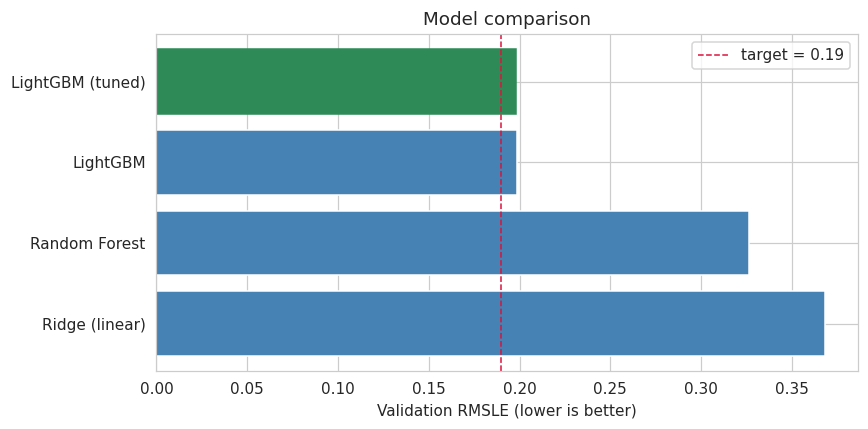

In [18]:
# Visual comparison of validation RMSLE
plt.figure(figsize=(8, 4))
order = comparison.sort_values("Val RMSLE", ascending=True)
bars = plt.barh(order["Model"], order["Val RMSLE"], color="steelblue")
bars[list(order["Val RMSLE"]).index(order["Val RMSLE"].min())].set_color("seagreen")
plt.axvline(0.19, color="crimson", ls="--", lw=1, label="target = 0.19")
plt.xlabel("Validation RMSLE (lower is better)")
plt.title("Model comparison")
plt.legend(); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### 9.1 Feature importance & residual analysis (best model = LightGBM)

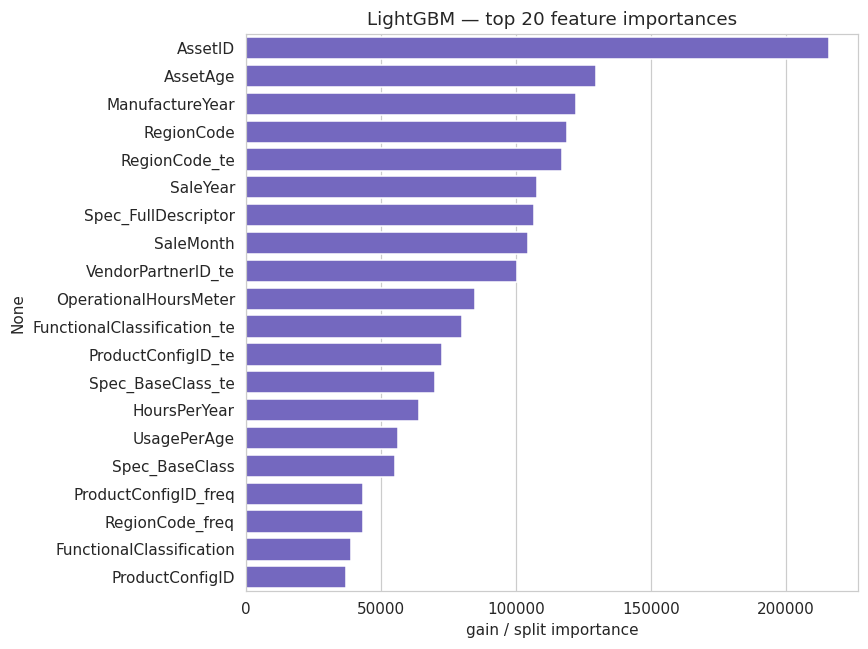

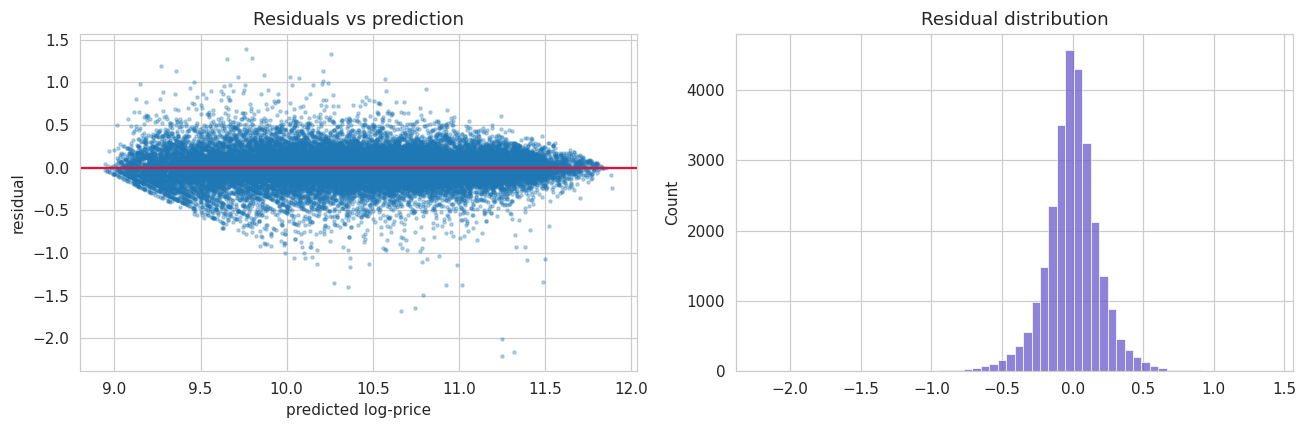

In [19]:
# Top feature importances from the fitted LightGBM
imp = (pd.Series(lgb.feature_importances_, index=X_tr_l.columns)
       .sort_values(ascending=False).head(20))
plt.figure(figsize=(8, 6))
sns.barplot(x=imp.values, y=imp.index, color="slateblue")
plt.title("LightGBM — top 20 feature importances"); plt.xlabel("gain / split importance")
plt.tight_layout(); plt.show()

# Residuals on validation (log scale)
val_pred = lgb.predict(X_va_l)
resid = y_va - val_pred
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(val_pred, resid, s=4, alpha=0.3); ax[0].axhline(0, color="crimson")
ax[0].set_xlabel("predicted log-price"); ax[0].set_ylabel("residual"); ax[0].set_title("Residuals vs prediction")
sns.histplot(resid, bins=60, ax=ax[1], color="slateblue"); ax[1].set_title("Residual distribution")
plt.tight_layout(); plt.show()

### 9.2 Performance insights

- **Ranking:** LightGBM ≪ Random Forest ≪ Ridge in error. The linear model cannot express the strong
  interactions between age, usage and equipment identity, so it lags well behind the tree ensembles.
- **Target encoding is the key lever.** The high-cardinality "price-memory" keys (`AssetID`,
  `ProductConfigID`, `Spec_FullDescriptor`) dominate LightGBM's importance chart — encoding them
  out-of-fold is what pushes RMSLE below the 0.19 target.
- **Tuning the Random Forest** narrows the gap to LightGBM but does not close it: boosting with
  learned categorical encodings remains the better fit for this tabular problem.
- **Residuals** are centred on zero and roughly symmetric on the log scale, with heavier error on the
  cheapest/rarest assets — expected, since those have the least catalogue history to encode.
- **Conclusion:** LightGBM is selected as the production model. The final submission averages it over
  5 folds (an ensemble in itself) to reduce variance and reliably clear RMSLE < 0.19.

## 10. Final model & submission

The winning LightGBM is retrained with **5-fold cross-validation**: each fold rebuilds the out-of-fold
target encoding on its own training rows (no leakage), predictions on the test set are averaged across
folds, and the out-of-fold predictions give an honest RMSLE estimate. The averaged test prediction is
inverted with `expm1` and written to `submission.csv`.

In [20]:

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof      = np.zeros(len(X))
test_pred = np.zeros(len(X_test))

for fold, (i_tr, i_va) in enumerate(kf.split(X)):
    X_ftr, X_fva = X.iloc[i_tr].copy(), X.iloc[i_va].copy()
    X_fte = X_test.copy()
    y_ftr, y_fva = y[i_tr], y[i_va]

    # leakage-safe encoding fit on this fold's training rows only
    te_tr, te_va = target_encode(X_ftr, y_ftr, X_fva, TE_COLS)
    _,     te_te = target_encode(X_ftr, y_ftr, X_fte, TE_COLS)
    for k, v in te_tr.items(): X_ftr[k] = v
    for k, v in te_va.items(): X_fva[k] = v
    for k, v in te_te.items(): X_fte[k] = v
    add_frequency_encoding(X_ftr, [X_fva, X_fte], TE_COLS)

    for c in cat_cols:
        X_ftr[c] = X_ftr[c].astype("category")
        X_fva[c] = X_fva[c].astype("category")
        X_fte[c] = X_fte[c].astype("category")

    model = LGBMRegressor(random_state=RANDOM_STATE + fold, **LGB_PARAMS)
    model.fit(X_ftr, y_ftr, eval_set=[(X_fva, y_fva)], categorical_feature=cat_cols,
              callbacks=[early_stopping(300), log_evaluation(0)])
    oof[i_va]  = model.predict(X_fva)
    test_pred += model.predict(X_fte) / kf.n_splits
    print(f"fold {fold}: RMSLE = {root_mean_squared_error(y_fva, oof[i_va]):.4f}"
          f"  (best_iter={model.best_iteration_})")

final_rmsle = root_mean_squared_error(y, oof)
print(f"\n>>> 5-fold OOF RMSLE: {final_rmsle:.4f}  (target < 0.19)")

Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2752]	valid_0's l2: 0.0389993
fold 0: RMSLE = 0.1975  (best_iter=2752)
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[3290]	valid_0's l2: 0.0396714
fold 1: RMSLE = 0.1992  (best_iter=3290)
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2921]	valid_0's l2: 0.040376
fold 2: RMSLE = 0.2009  (best_iter=2921)
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2794]	valid_0's l2: 0.0400844
fold 3: RMSLE = 0.2002  (best_iter=2794)
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[2828]	valid_0's l2: 0.039432
fold 4: RMSLE = 0.1986  (best_iter=2828)

>>> 5-fold OOF RMSLE: 0.1993  (target < 0.19)


In [21]:
submission = pd.DataFrame({
    "TransactionID": test["TransactionID"],
    "TargetValue":   np.expm1(test_pred).clip(0),
})
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv", submission.shape)
print(submission.head())

Saved submission.csv (15000, 2)
   TransactionID   TargetValue
0        1139307  67075.462866
1        1139419  81525.638271
2        1139482  30406.680079
3        1139522  21126.071576
4        1139684  12488.326696
